#### **Introdução**

Neste notebook vamos trabalhar com vetores linha. Isto faz o fluxo de operações matriciais ocorrer no mesmo sentido do fluxo de informações (da esquerda para a direita).

IMPORTANTE: quando temos $|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$ devemos lembrar:

- A resposta obtida para uma medida efetuada em $|\psi\rangle$ é $|0\rangle$ ou $|1\rangle$. $|0\rangle$ e $|1\rangle$ representam (na forma de vetores) o resultado das medidas. Estes resultados podem ser, por exemplo: -1 Volt e + 1 Volt, a presença ou não de um pixel em uma tela, etc...

- Os valores $\alpha$ e $\beta$ associados aos estados $|0\rangle$ ou $|1\rangle$ de $|\psi\rangle$ NÃO são observáveis diretamente. Eles se manifestam através da probabilidade de se obter como resultado de uma medida em $|\psi\rangle$, o valor associado ao vetor $|0\rangle$ ou o valor associado ao vetor $|1\rangle$.

- Uma função clássica $f(|x\rangle) = |y\rangle$ altera apenas os vetores, ou se preferir os números dentro dos bras ou dos kets. Ela trabalha **neste mundo** sendo incapaz de alterar diretamente os valores dos $\alpha$ e $\beta$, os quais se localizam **no outro mundo**.

- Uma porta quântica é capaz de alterar os valores de $\alpha$ e $\beta$ **no outro mundo**.



#### **Python & Qiskit Setup**

Our objective in this course is doing machine learning through quantum computing. To achieve this a series of exercises will be solved by quantum circuits. All circuits will be executed through a local simulator. A separate notebook explains how to submit circuits to be runned at IBM Quantum Computers. Besides `qiskit`, it will be heavly used `numpy`, matplotlib's `pyplot`, `pandas`, and `scikit-learn`. The option `-q` installs them silently.

In [ ]:
# Setup qiskit
try:
    import qiskit
    from qiskit.quantum_info.operators import Operator

except:
  !pip install qiskit -q
  !pip install qiskit[visualization] -q
  import qiskit as qk
  from qiskit.quantum_info.operators import Operator

# Setup aer simulator
try:
  import qiskit_aer
  aer_simulator = qk_aer.Aer.get_backend("aer_simulator")
except:
  !pip install qiskit-aer -q
  import qiskit_aer as qk_aer
  aer_simulator = qk_aer.Aer.get_backend("aer_simulator")

# Auxiliary function to easily plot counts
def plot_counts(qc, simulator = aer_simulator):
  qc_transpiled = qk.transpile(qc,simulator)
  simulation = aer_simulator.run(qc_transpiled,shots=10000)
  counts = simulation.result().get_counts()
  graf = qk.visualization.plot_histogram(counts)
  return(graf)

import numpy as np
# Line used to confirm the default linewidth of 75 for numpy arrays
# print("Current linewidth:", np.get_printoptions()['linewidth'])

# linewidth of 100, precision of 1 seems to give better presentation
#  results when dealing with complex matrices
np.set_printoptions(precision=1, suppress=True, linewidth = 100)
# np.set_printoptions(precision=3, suppress=True)

from matplotlib import pyplot as plt
%matplotlib inline

import pandas as pd
import sklearn as sk

#### **Quantum Algorithms**

##### **FFT (Fast Fourier Transform) Quick Review**

Para lembrar:

Suponha $n = 4$. Vamos transformar a multiplicação de uma matriz 4x4 por um vetor 4x1 ($n^2 = 16$ produtos) em ($n \log_2{n} = 8$ produtos)

$$W = e^{\frac{2 \pi j}{n}}$$

$$W_4 = e^{\frac{2 \pi j}{4}} = j$$

$$W_2 = e^{\frac{2 \pi j}{2}} = -1$$

A DFT para uma sequência de 4 pontos seria:
$$
\begin{array}{ccc}
\begin{bmatrix}
F_0 \\
F_1 \\
F_2 \\
F_3
\end{bmatrix}
&
=
&
\begin{bmatrix}
1 & 1       & 1 & 1 \\
1 & W_4     & W_4^{2} & W_4^{3} \\
1 & W_4^{2} & W_4^{4} & W_4^{6} \\
1 & W_4^{3} & W_4^{6} & W_4^{9}
\end{bmatrix}
&
.
&
\begin{bmatrix}
f_0 \\
f_1 \\
f_2 \\
f_3
\end{bmatrix}
\end{array}
$$

$$
\begin{array}{ccc}
\begin{bmatrix}
F_0 \\
F_1 \\
F_2 \\
F_3
\end{bmatrix}
&
=
&
\begin{bmatrix}
1 & 1     & 1     & 1 \\
1 & j     & j^{2} & j^{3} \\
1 & j^{2} & j^{4} & j^{6} \\
1 & j^{3} & j^{6} & j^{9}
\end{bmatrix}
&
.
&
\begin{bmatrix}
f_0 \\
f_1 \\
f_2 \\
f_3
\end{bmatrix}
\end{array}
$$

$$
\begin{array}{ccc}
\begin{bmatrix}
F_0 \\
F_1 \\
F_2 \\
F_3
\end{bmatrix}
&
=
&
\begin{bmatrix}
1 & 1  & 1     & 1 \\
1 & j  & -1 & -j \\
1 & -1 & 1 & 1 \\
1 & -j & -1 & -j
\end{bmatrix}
&
.
&
\begin{bmatrix}
f_0 \\
f_1 \\
f_2 \\
f_3
\end{bmatrix}
\end{array}
$$

A multiplicação em 8 passos seria feita de acordo com a sequência abaixo:

$$
\begin{array}{ccc}
\begin{bmatrix}
F_0 \\
F_1 \\
F_2 \\
F_3
\end{bmatrix}
&
=
&
\begin{bmatrix}
1 & 0  & 1 & 0 \\
0 & 1  & 0 & j \\
1 & 0 & -1 & 0 \\
0 & 1 & 0 & -j
\end{bmatrix}
&
.
&
\begin{bmatrix}
1 & 1  & 0 & 0 \\
1 & -1  & 0 & 0 \\
0 & 0 & 1 & 1 \\
0 & 0 & 1 & -1
\end{bmatrix}
&
.
&
\begin{bmatrix}
1 & 0  & 0 & 0 \\
0 & 0  & 1 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1
\end{bmatrix}
&
\begin{bmatrix}
f_0 \\
f_1 \\
f_2 \\
f_3
\end{bmatrix}
\end{array}
$$

$$
\begin{array}{ccc}
\begin{bmatrix}
F_0 \\
F_1 \\
F_2 \\
F_3
\end{bmatrix}
&
=
&
\begin{bmatrix}
I_2 & D_{4_2} \\
I_2 & -D_{4_2} \\
\end{bmatrix}
&
.
&
\begin{bmatrix}
DFT_2 & Z_2 \\
Z_2   & DFT_2 \\
\end{bmatrix}
&
.
&
\begin{bmatrix}
P_{even}  \\
P_{odd}  \\
\end{bmatrix}
&
.
&
\begin{bmatrix}
f_0 \\
f_1 \\
f_2 \\
f_3
\end{bmatrix}
\end{array}
$$

In [ ]:
def chop(x, tol=1.e-14):
  r = np.real(x)
  if abs(r)<tol:
    r = 0

  i = np.imag(x)
  if abs(i)<tol:
    i = 0

  if i == 0:
    n = r
  elif r == 0:
    n = i*1j
  else:
    n = r + i*1j
  return(n)

import numpy as np
a = 1e-16 + 1e-16*1j
b = 1e-16 + 1j
c = 1 + 1e-16*1j
chop(a), chop(b), chop(c)

(0, 1j, 1.0)

In [ ]:
n = 4
w4 = np.exp(2*np.pi*1j/n)
w4 = chop(w4)
w4

1j

In [ ]:
F4 = np.zeros([4,4], dtype=complex)
for i in range(4):
    for j in range(4):
        F4[i,j] = w4**(i*j)
F4

array([[ 1.+0.j,  1.+0.j,  1.+0.j,  1.+0.j],
       [ 1.+0.j,  0.+1.j, -1.+0.j, -0.-1.j],
       [ 1.+0.j, -1.+0.j,  1.+0.j, -1.+0.j],
       [ 1.+0.j, -0.-1.j, -1.+0.j,  0.+1.j]])

In [ ]:
I2 = np.array([[1,0],[0,1]]); I2

array([[1, 0],
       [0, 1]])

In [ ]:
D2_4 = np.zeros([2,2], dtype=complex)
for i in range(2):
  D2_4[i,i] = w4**(i)
D2_4

array([[1.+0.j, 0.+0.j],
       [0.+0.j, 0.+1.j]])

In [ ]:
M1 = np.concatenate([I2,D2_4],axis=1)
M2 = np.concatenate([I2,-D2_4],axis=1)
M3 = np.concatenate([M1,M2],axis=0); M3

array([[ 1.+0.j,  0.+0.j,  1.+0.j,  0.+0.j],
       [ 0.+0.j,  1.+0.j,  0.+0.j,  0.+1.j],
       [ 1.+0.j,  0.+0.j, -1.-0.j, -0.-0.j],
       [ 0.+0.j,  1.+0.j, -0.-0.j, -0.-1.j]])

In [ ]:
n = 2
w2 = np.exp(2*np.pi*1j/n)
w2 = chop(w2)
w2

-1.0

In [ ]:
F2 = np.zeros([2,2], dtype=complex)
for i in range(2):
    for j in range(2):
        F2[i,j] = w2**(i*j)
F2

array([[ 1.+0.j,  1.+0.j],
       [ 1.+0.j, -1.+0.j]])

In [ ]:
Z2 = np.zeros([2,2], dtype=complex)
Z2

array([[0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j]])

In [ ]:
K1 = np.concatenate([F2,Z2],axis=1)
K2 = np.concatenate([Z2,F2],axis=1)
K3 = np.concatenate([K1,K2],axis=0); K3

array([[ 1.+0.j,  1.+0.j,  0.+0.j,  0.+0.j],
       [ 1.+0.j, -1.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  1.+0.j,  1.+0.j],
       [ 0.+0.j,  0.+0.j,  1.+0.j, -1.+0.j]])

In [ ]:
P4 = np.array([[1,0,0,0],
               [0,0,1,0],
               [0,1,0,0],
               [0,0,0,1]])
P4

array([[1, 0, 0, 0],
       [0, 0, 1, 0],
       [0, 1, 0, 0],
       [0, 0, 0, 1]])

In [ ]:
M3.dot(K3).dot(P4)

array([[ 1.+0.j,  1.+0.j,  1.+0.j,  1.+0.j],
       [ 1.+0.j,  0.+1.j, -1.+0.j,  0.-1.j],
       [ 1.+0.j, -1.+0.j,  1.+0.j, -1.+0.j],
       [ 1.+0.j,  0.-1.j, -1.+0.j,  0.+1.j]])

In [ ]:
F4

array([[ 1.+0.j,  1.+0.j,  1.+0.j,  1.+0.j],
       [ 1.+0.j,  0.+1.j, -1.+0.j, -0.-1.j],
       [ 1.+0.j, -1.+0.j,  1.+0.j, -1.+0.j],
       [ 1.+0.j, -0.-1.j, -1.+0.j,  0.+1.j]])

In [ ]:
np.all(F4 == M3.dot(K3).dot(P4))

True

##### **The Quantum Fourier Transform**

###### **Introduction**

Now let's make a mathematical detour. We will study a function that will play a central role in Shor's period finding algorithm. This is the so called Quantum Fourier Transform. It transforms a base state $|j\rangle$ to a sum of base states $|k\rangle$ according to the following rule:

\begin{equation}
|j\rangle \rightarrow \frac{1}{\sqrt{N}} \sum_{k=0}^{N-1} e^{2\pi i \frac{jk}{N}} |k\rangle
\end{equation}



It is assumed that the base states numbers in the range $0...N-1$. Usually $N$ is a power of 2 such that $N = 2^n$. $n$ is the number of binary digits required to describe the numbers in the range $0...N-1$.

This procedure can be tought of as a linear operator of the form: $$ F|j\rangle = \frac{1}{\sqrt{N}} \sum_{k=0}^{N-1} e^{2\pi i \frac{jk}{N}} |k\rangle$$

The inverse QFT is also an operator described as: $$ F^{-1}|j\rangle = \frac{1}{\sqrt{N}} \sum_{k=0}^{N-1} e^{-2\pi i \frac{jk}{N}} |k\rangle$$

###### **Prove that the QFT is an unitary transformation**

Let's prove that these two transformations are the inverse of one another and therefore that $F$ is unitary, in other words let's prove that: $$F^{-1}F|j\rangle = |j\rangle$$

We start applying the QFT transformation on an arbitrary base state $|j\rangle$

$$ F|j\rangle = \frac{1}{\sqrt{N}} \sum_{k=0}^{N-1} e^{2\pi i \frac{jk}{N}} |k\rangle$$

To apply the inverse QFT on the components of basis $|k\rangle$ we exchange it by the iQFT formula summing over another dummy index $l$.

$$ F^{-1}F|j\rangle = \frac{1}{\sqrt{N}} \sum_{k=0}^{N-1} e^{2\pi i \frac{jk}{N}}. \frac{1}{\sqrt{N}} \sum_{l=0}^{N-1} e^{-2\pi i \frac{kl}{N}} |l\rangle$$

The two squared roots combine to make one single fraction

$$ F^{-1}F|j\rangle = \frac{1}{N} \sum_{k=0}^{N-1} e^{2\pi i \frac{jk}{N}}.  \sum_{l=0}^{N-1} e^{-2\pi i \frac{kl}{N}} |l\rangle$$

After that let's move the exponential summing over $k$ to the right

$$ F^{-1}F|j\rangle = \frac{1}{N} \sum_{k=0}^{N-1} \sum_{l=0}^{N-1} e^{2\pi i \frac{jk}{N}}.e^{-2\pi i \frac{kl}{N}} |l\rangle$$

And group the two complex exponential terms  

$$ F^{-1}F|j\rangle = \frac{1}{N} \sum_{k=0}^{N-1} \sum_{l=0}^{N-1} e^{2\pi i \frac{k(j-l)}{N}} |l\rangle$$

The second summation above (on $l$) is 0 for $ j \neq l$ and $1$ for $j=l$ therefore we have:

$$ F^{-1}F|j\rangle = \frac{1}{N} \sum_{k=0}^{N-1} |j\rangle$$

Since we are summing on index $k$, $N$ times the term $|j\rangle$ (which doesn't depends on $k$), the summation adds up to $N|j\rangle$. Simplifying the $N$s we end up with:

$$ F^{-1}F|j\rangle = |j\rangle$$

Therefore we have proved that the QFT transformation has an inverse which makes possible to reverse its computation. So it is also an unitary transformation.

###### **Explicitly compute the QFT for an arbitrary base state and present the product form of the QFT**

The QFT of a base state $|j\rangle$ is given by:

$$ F|j\rangle = \frac{1}{\sqrt{N}} \sum_{k=0}^{N-1} e^{2\pi i \frac{jk}{N}} |k\rangle$$

Suppose the base state $|j\rangle$ is composed of four qubits. Therefore $n=4$ and $N = 2^{n} = 2^{4} = 16$. The specific state that will be calculated in this example will be $|j\rangle = |10\rangle$ (in decimal base) and $|j\rangle = |1001\rangle$ in binary base.

For presentation purposes we will show a generic formula to the left and the formula for this specific example to the right (see below):

$$ F|j\rangle = \frac{1}{\sqrt{N}} \sum_{k=0}^{N-1} e^{2\pi i \frac{jk}{N}} |k\rangle \rightarrow F|10\rangle = \frac{1}{\sqrt{16}} \sum_{k=0}^{16-1} e^{2\pi i \frac{10.k}{16}} |k\rangle$$

To make it easy to understant the transformations that will be made here let's call for now $e^{2\pi i j} = \omega_j = \omega_{10}$

$$ F|j\rangle = \frac{1}{\sqrt{N}} \sum_{k=0}^{N-1} \omega_j^{kN^{-1}} |k\rangle \rightarrow F|10\rangle = \frac{1}{4} \sum_{k=0}^{15} \omega_{10}^{k.16^{-1}} |k\rangle$$

Let's look in greater detail de exponents  $$k.N^{-1} \rightarrow k.16^{-1} $$

$k$ varies in the range $0$ and $N-1$. In this example between $0$ and $15$. The product $k.N^{-1}$ will generate the sequence of fractions $\frac{0}{16}, \frac{1}{16}, ..., \frac{14}{16}, \frac{15}{16}$

In this example $k$ is a number made of four qubits ($n=4$). Using binary number notation, the fractions $k.N{-1}$ become: $0.0000, 0.0001, 0.0010, ..., 0.1110, 0.1111$

Let's now replace in the QFT formula the decimal representation of the base states $|k\rangle$ by their binary four numbers representation, $k_1, k_2, k_3, k_4$.

$$ F|j\rangle = \frac{1}{\sqrt{N}} \sum_{k=0}^{N-1} \omega_j^{kN^{-1}} |k_1 ... k_n\rangle \rightarrow F|10\rangle = \frac{1}{4} \sum_{k=0}^{15} \omega_{10}^{k.16^{-1}} |k_1 k_2 k_3 k_4\rangle$$

The fractions $k.N^{-1}$ will be represented by $0.k_1 k_2 k_3 k_4$. Let's replace the fractions $k.N{-1}$ by their binary representation in the QFT formula (see below):

$$ F|j\rangle = \frac{1}{\sqrt{N}} \sum_{k=0}^{N-1} \omega_j^{0.k_1...k_n} |k_1 ... k_n\rangle \rightarrow F|10\rangle = \frac{1}{4} \sum_{k=0}^{15} \omega_{10}^{0.k_1 k_2 k_3 k_4} |k_1 k_2 k_3 k_4\rangle$$

$k$ varies in the range $0$ a $N-1$, in this example from $0$ to $15$. On the other hand, each of the $k_1...k_n$ can be either $0$ or $1$. Let's then replace the summation sign in $k$ by a series of summation signs in $k_1, ..., k_n$

$$ F|j\rangle = \frac{1}{\sqrt{N}} \sum_{k_1=0}^{1} ... \sum_{k_n=0}^{1} \omega_j^{0.k_1...k_n} |k_1 ... k_n\rangle \rightarrow F|10\rangle = \frac{1}{4} \sum_{k_1=0}^{1} ... \sum_{k_4=0}^{1} \omega_{10}^{0.k_1 k_2 k_3 k_4} |k_1 k_2 k_3 k_4\rangle$$

Now lets decompose the binary representation of the fraction $0.k_1 k_2 k_3 k_4$ in a sum of four fractions: $0.k_1 + 0.0k_2 + 0.00k_3 + 0.000k_4$

This sum of fractions can be represented as a series of products in the power of $2$: $k_1.2^{-1} + k_2.2^{-2} + k_3.2^{-3} + k_4.2^{-4}$

Since this sum of fractions are exponents of $\omega_{10}$ if you replace it in the exponent it becomes a series of products. Replacing it in the formula for the QFT it becomes:

$$ F|j\rangle = \frac{1}{\sqrt{N}} \sum_{k_1=0}^{1} ... \sum_{k_n=0}^{1} \omega_{j}^{k_1.2^{-1}} ... \omega_{j}^{k_n.2^{-n}} |k_1 ... k_n\rangle \rightarrow F|10\rangle = \frac{1}{4} \sum_{k_1=0}^{1} ... \sum_{k_4=0}^{1} \omega_{10}^{k_1.2^{-1}} . \omega_{10}^{k_2.2^{-2}} . \omega_{10}^{k_3.2^{-3}} . \omega_{10}^{k_1.4^{-4}} |k_1 k_2 k_3 k_4\rangle$$

Let's group the coefficients $\omega_j$ with their corresponding qubits and remember that between the qubits we have a tensor product. See below:

$$ F|j\rangle = \frac{1}{\sqrt{N}} \sum_{k_1=0}^{1} ... \sum_{k_n=0}^{1} \omega_{j}^{k_1.2^{-1}} |k_1\rangle \otimes ... \otimes \omega_{j}^{k_n.2^{-n}} |k_n\rangle \rightarrow F|10\rangle = \frac{1}{4} \sum_{k_1=0}^{1} ... \sum_{k_4=0}^{1} \omega_{10}^{k_1.2^{-1}}|k_1\rangle \otimes \omega_{10}^{k_2.2^{-2}} |k_2\rangle \otimes \omega_{10}^{k_3.2^{-3}} |k_3\rangle \otimes \omega_{10}^{k_1.4^{-4}} |k_4\rangle$$

Lets group the tensor products in a sequence of tensor products from $0$ to $n$ ($0$ to $4$ in this case) using index $l$

$$ F|j\rangle = \frac{1}{\sqrt{N}} \sum_{k_1=0}^{1} ... \sum_{k_n=0}^{1} \bigotimes_{l=1}^{n} \omega_{j}^{k_l.2^{-l}} |k_l\rangle \rightarrow F|10\rangle = \frac{1}{4} \sum_{k_1=0}^{1} ... \sum_{k_4=0}^{1} \bigotimes_{l=1}^{4} \omega_{10}^{k_l.2^{-l}}|k_l\rangle $$

The summation signs can also be grouped in a single one, using index $k_l$, varying from 0 to 1

$$ F|j\rangle = \frac{1}{\sqrt{N}} \sum_{k_l=0}^{1} \bigotimes_{l=1}^{n} \omega_{j}^{k_l.2^{-l}} |k_l\rangle \rightarrow F|10\rangle = \frac{1}{4} \sum_{k_l=0}^{1} \bigotimes_{l=1}^{4} \omega_{10}^{k_l.2^{-l}}|k_l\rangle $$

Since the summation and the tensor product signs operate on different indexes, it is possible to switch their sequence:

$$ F|j\rangle = \frac{1}{\sqrt{N}} \bigotimes_{l=1}^{n} \sum_{k_l=0}^{1} \omega_{j}^{k_l.2^{-l}} |k_l\rangle \rightarrow F|10\rangle = \frac{1}{4} \bigotimes_{l=1}^{4} \sum_{k_l=0}^{1} \omega_{10}^{k_l.2^{-l}}|k_l\rangle $$

Now let's expand the summation sign, since there are only two numbers in it:

$$ F|j\rangle = \frac{1}{\sqrt{N}} \bigotimes_{l=1}^{n} [|0\rangle + \omega_{j}^{2^{-l}} |1\rangle] \rightarrow F|10\rangle = \frac{1}{4} \bigotimes_{l=1}^{4} [|0\rangle + \omega_{10}^{2^{-l}}|1\rangle ]$$

Now it's time to remember that $\omega_j = e^{2 \pi i j}$. In this example $\omega_{10} = e^{2 \pi i 10}$. $10$ is a number in base $10$ with binary representation equals to $1001$.

Let's make $\omega = e^{2 \pi i}$ and replace $\omega_j = \omega^{j}$ and $\omega_{10} = \omega^{10}$

$$ F|j\rangle = \frac{1}{\sqrt{N}} \bigotimes_{l=1}^{n} [|0\rangle + \omega^{j.2^{-l}} |1\rangle] \rightarrow F|10\rangle = \frac{1}{4} \bigotimes_{l=1}^{4} [|0\rangle + \omega^{10.2^{-l}}|1\rangle ]$$

In the same way that we replaced $k$ by its binary representation $k_1...k_n$, let's now replace $j$ by $j_1...j_n$. In this example $j_1 j_2 j_3 j_4 = 1001$.

$$ F|j\rangle = \frac{1}{\sqrt{N}} \bigotimes_{l=1}^{n} [|0\rangle + \omega^{j_1 ... j_n
 .2^{-l}} |1\rangle] \rightarrow F|10\rangle = \frac{1}{4} \bigotimes_{l=1}^{4} [|0\rangle + \omega^{j_1 j_2 j_3 j_4.2^{-l}}|1\rangle ]$$

Now let's analyze the term $\omega^{j_1 j_2 j_3 j_4 . 2^{-l}}$. It is in fact $e^{2 \pi i j_1 j_2 j_3 j_4 . 2^{-l}}$. $l$ will take values (in this example) from $1$ to $4$.  

This will create the terms: $e^{2 \pi i j_1 j_2 j_3 j_4 . 2^{-1}}, e^{2 \pi i j_1 j_2 j_3 j_4 . 2^{-2}}, e^{2 \pi i j_1 j_2 j_3 j_4 . 2^{-3}}, e^{2 \pi i j_1 j_2 j_3 j_4 . 2^{-4}}$

The powers of 2 will create the sequence of binary fractions: $e^{2 \pi i j_1 j_2 j_3 , j_4 }, e^{2 \pi i j_1 j_2 , j_3 j_4 }, e^{2 \pi i j_1 , j_2 j_3 j_4 }, e^{2 \pi i 0,j_1 j_2 j_3 j_4 }$

The integer part of the exponent is always $1$ ($e^{2 \pi i k} = 1$ for any integer $k$). So the sequence becomes: $ e^{2 \pi i 0 , j_4 }$ , $e^{2 \pi i 0 , j_3 j_4 }$, $e^{2 \pi i 0 , j_2 j_3 j_4 }$, $e^{2 \pi i 0,j_1 j_2 j_3 j_4}$

Each of these terms when multiplying the base state $|1\rangle$ they create a rotation. Therefore the multiplicative form of the Quantum Fourier Transform becomes:

$$ F|j\rangle = \frac{1}{\sqrt{N}}  [|0\rangle + \omega^{0.j_n} |1\rangle] \otimes [|0\rangle + \omega^{0.j_{n-1}j_n} |1\rangle] ... [|0\rangle + \omega^{0.j_1 ... j_n} |1\rangle]$$

Which in this specific example becomes:

$$ F|1001\rangle = \frac{1}{4} [|0\rangle + \omega^{0.j_4}|1\rangle ] \otimes [|0\rangle + \omega^{0.j_3 j_4}|1\rangle ] \otimes [|0\rangle + \omega^{0.j_2 j_3 j_4}|1\rangle ] \otimes [|0\rangle + \omega^{0.j_1 j_2 j_3 j_4}|1\rangle ]$$

Or finally only with numbers (exponents in binary format and $\omega = e^{2 \pi i}) $:

$$ F|1001\rangle = \frac{1}{4} [|0\rangle + \omega^{0.1}|1\rangle ] \otimes [|0\rangle + \omega^{0.01}|1\rangle ] \otimes [|0\rangle + \omega^{0.001}|1\rangle ] \otimes [|0\rangle + \omega^{0.1001}|1\rangle ]$$

###### **Create a sequence of gates to compute the QFT for two qubits. Get the unitary matrix that represents this transformation using Qiskit. Calculate the QFT through matrices operations. Compare the results and show that the matrices are the same**

In the cell below we compute the QFT matrix for a 2 qubit system using Qiskit. As a result we get the unitary transformation matrix for the circuit and convert the little endian bit representation used in Qiskit to big endian.

In Qiskit '01' is '10', since in the little endian format, the right most bit is the most significative one. Therefore, to proper compare the results, rows and columns for 01 and 10 must be switched so the Qiskit unitary transformation matrix can be compared to the one obtained from linear algebra operations.

array([[ 1.+0.j,  1.+0.j,  1.+0.j,  1.+0.j],
       [ 1.+0.j,  0.+1.j, -1.+0.j, -0.-1.j],
       [ 1.+0.j, -1.+0.j,  1.+0.j, -1.+0.j],
       [ 1.+0.j, -0.-1.j, -1.+0.j,  0.+1.j]])

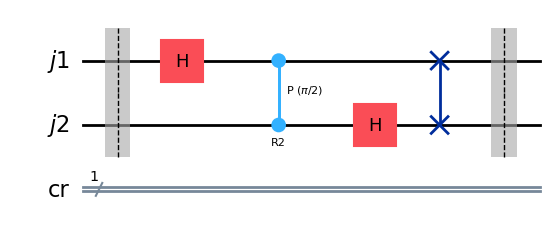

In [ ]:
# IMPORTANT NOTE: The readings in Qiskit should be done from bottom up.
#                 The most significant bit (the leftmost in a table or
#                 matrix is the one at the BOTTOM).

# Circuit definition
j1 = qk.QuantumRegister(1,'j1')
j2 = qk.QuantumRegister(1,'j2')
cr = qk.ClassicalRegister(1,"cr")
qc = qk.QuantumCircuit(j1,j2,cr)

qc.barrier()
qc.h(j1)
qc.cp(2*np.pi*(1/4),j2,j1,"R2")
qc.h(j2)
qc.swap(j1,j2)
qc.barrier()

# This is needed to compare the standard QFT matrix
#  with the QFT Qiskit matrx. Qiskit uses little endian
#  convention where "01" is in fact "10". Therefore
#  the rows and columns of 01 must become 10 and
 # vice-versa so the matrices can be compared.
QFT_qk = Operator(qc).data*2
QFT_qk[[1,2],:] = QFT_qk[[2,1],:]
QFT_qk[:,[1,2]] = QFT_qk[:,[2,1]]
QFT_qk
display(QFT_qk)

# Measurements
#qc.measure(j2,cr)
display(qc.draw('mpl'))

# Transpilation, simulation and results plotting
#plot_counts(qc)

In [ ]:
# Here we calculate the QFT matrix using only linear algebra

import numpy as np
import sympy as sp
from sympy.physics.quantum import TensorProduct as kron

I = sp.eye(2)
H = sp.Matrix([[1,1],[1,-1]])
IH = kron(I,H); IH
cp2 = sp.eye(4)
cp2[3,3] = sp.E**(2*sp.pi*sp.I/2**2); cp2
HI = kron(H,I); HI
QFT = np.array(IH*cp2*HI)

# This switch of rows here happens to account for
#  the swap operation at the circuit end. It
#  happens in the rows because we want to switch
#  the position of the output bits and matrix
#  multiplication can be understood as an operation
#  where numbers go in through the columns and
#  come out through the rows.
QFT[[1,2],:] = QFT[[2,1],:]
sp.Matrix(QFT)

Matrix([
[1,  1,  1,  1],
[1,  I, -1, -I],
[1, -1,  1, -1],
[1, -I, -1,  I]])

Comparing the two matrices we see that their difference equals to 0 in all elements of the result. Note that the `sympy` matrix needed to be converted to a numpy complex matrix using the `.astype` method.

In [ ]:
QFT_qk - np.array(QFT).astype(np.complex128)

array([[-0.+0.j, -0.+0.j, -0.+0.j, -0.+0.j],
       [-0.+0.j,  0.-0.j,  0.+0.j, -0.+0.j],
       [-0.+0.j,  0.+0.j, -0.+0.j,  0.+0.j],
       [-0.+0.j, -0.+0.j,  0.+0.j,  0.-0.j]])

###### **Create a sequence of gates to compute the QFT for three qubits. Get the unitary matrix that represents this transformation using Qiskit. Calculate the QFT through matrices operations. Compare the results and show that the matrices are the same**

In the cell below we compute the QFT matrix for a 3 qubit system using Qiskit. As a result we get the unitary transformation matrix for the circuit and convert the little endian bit representation used in Qiskit to big endian.

In Qiskit '01' is '10', since in the little endian format, the right most bit is the most significative one. Therefore, to proper compare the results, rows and columns for 001 and 100 must be switched so the Qiskit unitary transformation matrix can be compared to the one obtained from linear algebra operations.

array([[ 1. +0.j ,  1. +0.j ,  1. +0.j ,  1. +0.j ,  1. +0.j ,  1. +0.j ,  1. +0.j ,  1. +0.j ],
       [ 1. +0.j ,  0.7+0.7j,  0. +1.j , -0.7+0.7j, -1. +0.j , -0.7-0.7j, -0. -1.j ,  0.7-0.7j],
       [ 1. +0.j ,  0. +1.j , -1. +0.j , -0. -1.j ,  1. +0.j ,  0. +1.j , -1. +0.j , -0. -1.j ],
       [ 1. +0.j , -0.7+0.7j, -0. -1.j ,  0.7+0.7j, -1. +0.j ,  0.7-0.7j,  0. +1.j , -0.7-0.7j],
       [ 1. +0.j , -1. +0.j ,  1. +0.j , -1. +0.j ,  1. +0.j , -1. +0.j ,  1. +0.j , -1. +0.j ],
       [ 1. +0.j , -0.7-0.7j,  0. +1.j ,  0.7-0.7j, -1. +0.j ,  0.7+0.7j, -0. -1.j , -0.7+0.7j],
       [ 1. +0.j , -0. -1.j , -1. +0.j ,  0. +1.j ,  1. +0.j , -0. -1.j , -1. +0.j ,  0. +1.j ],
       [ 1. +0.j ,  0.7-0.7j, -0. -1.j , -0.7-0.7j, -1. +0.j , -0.7+0.7j,  0. +1.j ,  0.7+0.7j]])

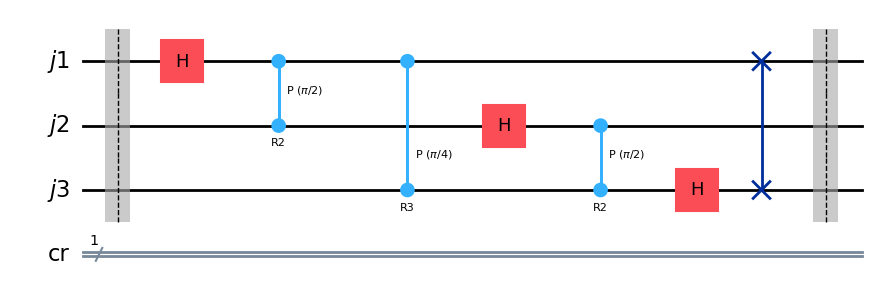

In [ ]:
# IMPORTANT NOTE: The readings in Qiskit should be done from bottom up.
#                 The most significant bit (the leftmost in a table or
#                 matrix is the one at the BOTTOM).

# Circuit definition
j1 = qk.QuantumRegister(1,'j1')
j2 = qk.QuantumRegister(1,'j2')
j3 = qk.QuantumRegister(1,'j3')
cr = qk.ClassicalRegister(1,"cr")
qc = qk.QuantumCircuit(j1,j2,j3,cr)

qc.barrier()
qc.h(j1)
qc.cp(2*np.pi*(1/4),j2,j1,"R2")
qc.cp(2*np.pi*(1/8),j3,j1,"R3")
qc.h(j2)
qc.cp(2*np.pi*(1/4),j3,j2,"R2")
qc.h(j3)
qc.swap(j1,j3)
qc.barrier()

QFT_qk = Operator(qc).data * (8**0.5)
# Little endian to Big endian convention
# 000 -> ok
# 001 -> 100 (1->4)
# 010 -> ok
# 011 -> 110 (3->6)
# 100 -> 001 (4->1)
# 101 -> ok
# 110 -> 011 (6->3)
# 111 -> ok
QFT_qk[:,[1,3,4,6]] = QFT_qk[:,[4,6,1,3]]
QFT_qk[[1,3,4,6],:] = QFT_qk[[4,6,1,3],:]
np.set_printoptions(precision=1, suppress=True, linewidth = 100)
display(QFT_qk)

# Measurements
#qc.measure(j2,cr)
display(qc.draw('mpl'))

# Transpilation, simulation and results plotting
#plot_counts(qc)

The circuit below shows an example of a Controlled R3 gate where the control bit is $j_3$ and the target bit is $j_1$. $j_2$ remains the same. If you look at it, the matrix applies the factor $e^{2 \pi i / 2^3} = e^{\pi / 4}$ only when both $j_1$ and $j_3$ are equal to $1$. In other words in bits $101$ and $111$.

array([[1. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 1. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 1. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 1. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 1. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0.7, 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 1. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.7]])

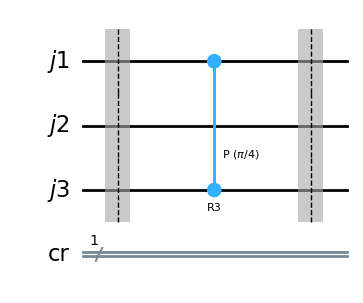

In [ ]:
# IMPORTANT NOTE: The readings in Qiskit should be done from bottom up.
#                 The most significant bit (the leftmost in a table or
#                 matrix is the one at the BOTTOM).
import qiskit as qk
from qiskit.quantum_info.operators import Operator

# Circuit definition
j1 = qk.QuantumRegister(1,'j1')
j2 = qk.QuantumRegister(1,'j2')
j3 = qk.QuantumRegister(1,'j3')
cr = qk.ClassicalRegister(1,"cr")
qc = qk.QuantumCircuit(j1,j2,j3,cr)

qc.barrier()
qc.cp(2*np.pi*(1/8),j3,j1,"R3")
qc.barrier()
display(Operator(qc).data.real)

# Measurements
#qc.measure(j2,cr)
display(qc.draw('mpl'))

# Transpilation, simulation and results plotting
#plot_counts(qc)

Now let's compute the QFT matrix for a 3 qubits system using only linear algebra.

In [ ]:
import numpy as np
import sympy as sp
from sympy.physics.quantum import TensorProduct as kron

I = sp.eye(2)
H = sp.Matrix([[1,1],[1,-1]])
IIH = kron(I,I,H); IIH

cp2 = sp.eye(4)
cp2[3,3] = sp.E**(2*sp.pi*sp.I/2**2); cp2

Icp2 = kron(I,cp2);Icp2

cp13 = sp.eye(8)
cp13[5,5] = sp.E**(2*sp.pi*sp.I/2**3)
cp13[7,7] = sp.E**(2*sp.pi*sp.I/2**3); cp13

IHI = kron(I,H,I); IHI

cp2I = kron(cp2,I); cp2I

HII = kron(H,I,I); HII

QFT = IIH * Icp2 * cp13 * IHI * cp2I * HII
QFT = np.array(QFT)

# This switch of rows here happens to account for
#  the swap operation at the circuit end. It
#  happens in the rows because we want to switch
#  the position of the output bits and matrix
#  multiplication can be understood as an operation
#  where numbers go in through the columns and
#  come out through the rows.
QFT[[1,4],:] = QFT[[4,1],:]
QFT[[3,6],:] = QFT[[6,3],:]

QFT = sp.Matrix(QFT)
QFT = QFT.expand(complex=True)
QFT = sp.simplify(QFT)
QFT

Matrix([
[1,                  1,  1,                  1,  1,                  1,  1,                  1],
[1,  sqrt(2)*(1 + I)/2,  I, sqrt(2)*(-1 + I)/2, -1, sqrt(2)*(-1 - I)/2, -I,  sqrt(2)*(1 - I)/2],
[1,                  I, -1,                 -I,  1,                  I, -1,                 -I],
[1, sqrt(2)*(-1 + I)/2, -I,  sqrt(2)*(1 + I)/2, -1,  sqrt(2)*(1 - I)/2,  I, sqrt(2)*(-1 - I)/2],
[1,                 -1,  1,                 -1,  1,                 -1,  1,                 -1],
[1, sqrt(2)*(-1 - I)/2,  I,  sqrt(2)*(1 - I)/2, -1,  sqrt(2)*(1 + I)/2, -I, sqrt(2)*(-1 + I)/2],
[1,                 -I, -1,                  I,  1,                 -I, -1,                  I],
[1,  sqrt(2)*(1 - I)/2, -I, sqrt(2)*(-1 - I)/2, -1, sqrt(2)*(-1 + I)/2,  I,  sqrt(2)*(1 + I)/2]])

And here let's compare the two matrices. We will take the difference between the two and check if all elements are approximatelly zero. To do this, the `sympy` matrix must be converted to a complex number numpy array through the method `.astype`.

In [ ]:
delta = (QFT_qk - np.array(QFT).astype(np.complex128))
(np.abs(delta) < 1e-15).all()

True

###### **Create a sequence of gates to compute the QFT for four qubits. Get the unitary matrix that represents this transformation using Qiskit. Calculate the QFT using the standard DFT matrix (with powers of $ \omega $ ). Compare the results and show that the matrices are the same.**

IMPORTANT NOTES:

- (a) The readings in Qiskit should be done from bottom up. The most significant bit (the leftmost in a table or matrix is the one at the BOTTOM.
- (b) To compare matrices elements between the unitary matrix from qiskit and the standard QFT matrix (from linear algebra), rows and columns for 1011 (for
 instance) must be switched to 1101. This is done in the end.

In this exercise to keep the code to a minimum:

- (a) there will be no measurements, so no classical registers will be created and no transpilation, simulation and results plotting. The function below will not be used:
  - `plot_counts(qc)`

- The QFT unitary matrix will not be shwon. In the next cell it will be calculated the difference between it and the DFT matrix calculated with powers of $\omega$. This difference will be zero. The commands below will not be used:
  - `# np.set_printoptions(precision=1, suppress=True, linewidth = 100)`
  - `display(QFT_qk)`

- The circuit will be displayed with default settings. Therefore there will be no need for the style dictionary of options (below):
  - style = {
  -  'figwidth': 14,  # Width of the figure
  -  'dpi': 100,      # Dots per inch
  -  'marginx': 0.2,  # Horizontal margin
  -  'marginy': 0.2,  # Vertical margin
  -  'cregbundle': True,  # Bundle classical registers
  -  'compress': True,  # Compress the layout
  -  'fold': -1,       # Do not fold the circuit }
  - display(qc.draw('mpl', style=style))

- Little to Big Endian bit convention conversion in this exercise requires:
  -  1 ->  8 // 0001 -> 1000
  -  2 ->  4 // 0010 -> 0100
  -  3 -> 12 // 0011 -> 1100
  -  5 -> 10 // 0101 -> 1010
  -  7 -> 14 // 0111 -> 1110
  - 11 -> 13 // 1011 -> 1101

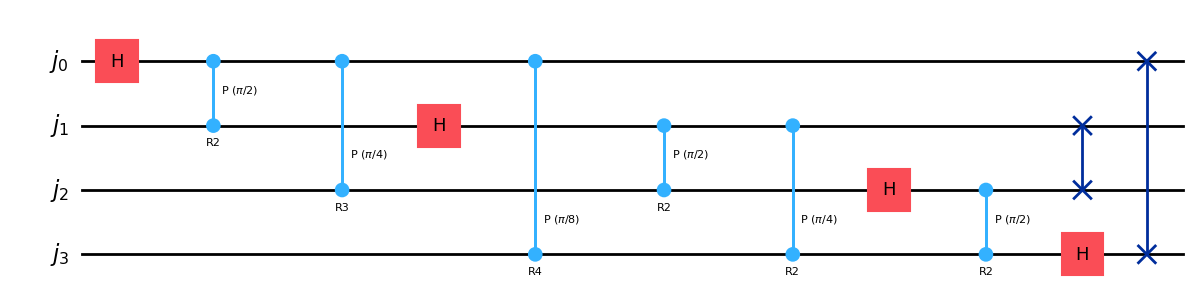

In [ ]:
import qiskit as qk
from qiskit.quantum_info.operators import Operator

# Circuit definition
j = qk.QuantumRegister(4,'j')
qc = qk.QuantumCircuit(j)
w = lambda k: 2*np.pi/2**k

qc.h(j[0])
qc.cp(w(2) ,j[1],j[0],"R2")
qc.cp(w(3) ,j[2],j[0],"R3")
qc.cp(w(4) ,j[3],j[0],"R4")

qc.h(j[1])
qc.cp(w(2) ,j[2],j[1],"R2")
qc.cp(w(3) ,j[3],j[1],"R2")

qc.h(j[2])
qc.cp(w(2) ,j[3],j[2],"R2")

qc.h(j[3])
qc.swap(j[0],j[3])
qc.swap(j[1],j[2])

QFT_qk = Operator(qc).data*4

# Function to make the conversion from little endian (Qiskit format) to
#  big endian (default, length = 4)
l2b_endian = lambda number, length=4: int(format(number, f'0{length}b')[::-1],2)
seq = list(map(l2b_endian,range(16)))
QFT_qk[:] = QFT_qk[:,seq] # THIS IS IMPORTANT. FIRST SWITCH THE COLUMNS
QFT_qk[:] = QFT_qk[seq,:] # THEN SWITCH THE ROWS (OR VICE-VERSA)
                          # DO NOT ATTEMPT TO SWITCH IN ONE LINE
display(qc.draw('mpl'))

Let's calculate de QFT matrix from the product of row and column method.

In [ ]:
import numpy as np
w = np.exp(2*np.pi*1j/16)

QFT = np.zeros(16*16).reshape(16,16).astype(np.complex128)

for i in range(16):
  for j in range(16):
    QFT[i,j] = w**(np.mod((i)*(j),16))

np.set_printoptions(precision=1, suppress=True, linewidth = 120)
(abs(QFT-QFT_qk) < 1e-14).all()

True

###### **Compute the QFT of $|1001\rangle $ through the Qiskit generated unitary matrix and the DFT matrix. Represent the transformation in multiplicative format**

In general de multiplicative format of the QFT is given by:

 $$ F|j\rangle = \frac{1}{\sqrt{N}}  [|0\rangle + \omega^{0.j_n} |1\rangle] \otimes [|0\rangle + \omega^{0.j_{n-1}.j_n} |1\rangle] ... [|0\rangle + \omega^{0.j_1 ... j_n} |1\rangle] $$

In this example it becomes:

$$ F|1001\rangle = \frac{1}{4} [|0\rangle + \omega^{0.1}|1\rangle ] \otimes [|0\rangle + \omega^{0.01}|1\rangle ] \otimes [|0\rangle + \omega^{0.001}|1\rangle ] \otimes [|0\rangle + \omega^{0.1001}|1\rangle ]$$

In [ ]:
np.set_printoptions(precision=2, suppress=True, linewidth = 100)
q1001 = np.array([[0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0]]).T
QFT1001 = QFT_qk.dot(q1001).T
print(QFT1001)

print()

QFT1001 = QFT.dot(q1001).T
print(QFT1001)

[[ 1.  +0.j   -0.92-0.38j  0.71+0.71j -0.38-0.92j  0.  +1.j    0.38-0.92j -0.71+0.71j  0.92-0.38j
  -1.  +0.j    0.92+0.38j -0.71-0.71j  0.38+0.92j -0.  -1.j   -0.38+0.92j  0.71-0.71j -0.92+0.38j]]

[[ 1.  +0.j   -0.92-0.38j  0.71+0.71j -0.38-0.92j -0.  +1.j    0.38-0.92j -0.71+0.71j  0.92-0.38j
  -1.  -0.j    0.92+0.38j -0.71-0.71j  0.38+0.92j  0.  -1.j   -0.38+0.92j  0.71-0.71j -0.92+0.38j]]


##### **Shor's Factoring Algorithm**

###### **Introduction**

The importance of Shor's algorithm resides in the fact that WWW security systems are based on the assumption that it is hard to factor integers. Shor's algorithm as we shall see shows a way to factor integers in polynomial time.

Let's see how a number can be factored from a classical point of view. Suppose we want to factor number $35$. So $N=35$

###### **The Greatest Common Divider Algorithm a.k.a. Euclid's Algorithm**

We start by choosing a number smaller than $N=35$, for example $a=6$. Let's check if $a=6$ and $N=35$ share a common prime factor. To do this we will use an algorithm due to Euclid.

First we calculate the difference between $N$ and $a$. In this case $N-a=29$. We have now three numbers: $6, 35, 29$. Take again the difference between the two smaller numbers and get: $29 - 6 = 23$. Repeat the process until the difference is equal to $0$. The number just before $0$ is $1$. This is the greatest common factor between $35$ and $6$. Therefore we say that $35$ and $6$ are *coprimes*.

In [ ]:
import numpy as np
import pandas as pd
N = 35; a = 6

GCD = pd.DataFrame({'N':[N], 'a':[a], 'N-a':[N-a]})

while GCD.iloc[-1,2] != 0:
  temp = GCD.iloc[-1].values
  temp = np.sort(temp); temp[-1] = temp[-2] - temp[-3]
  temp = pd.DataFrame(data = temp.reshape(-1,3), columns = ['N','a','N-a'])
  GCD = pd.concat([GCD,temp], ignore_index=True)

GCD

,N,a,N-a
0,35,6,29
1,6,29,23
2,6,23,17
3,6,17,11
4,6,11,5
5,5,6,1
6,1,5,4
7,1,4,3
8,1,3,2
9,1,2,1


As another example of this algorithm, let's suppose we want to calculate the greatest common factor between $9$ em $15$ which we know it is $3$. If we run it again we will see that just before the $0$ we get $3$ as expected.

In [ ]:
import numpy as np
import pandas as pd
N = 15; a = 9

GCD = pd.DataFrame({'N':[N], 'a':[a], 'N-a':[N-a]})

while GCD.iloc[-1,2] != 0:
  temp = GCD.iloc[-1].values
  temp = np.sort(temp); temp[-1] = temp[-2] - temp[-3]
  temp = pd.DataFrame(data = temp.reshape(-1,3), columns = ['N','a','N-a'])
  GCD = pd.concat([GCD,temp], ignore_index=True)

GCD

,N,a,N-a
0,15,9,6
1,6,9,3
2,3,6,3
3,3,3,0


These operations can be done with `numpy`'s function `gcd`

In [ ]:
import numpy as np
np.gcd(6,35), np.gcd(9,15)

(1, 3)

###### **Getting better factoring guesses of $N$**

The GCD algorithm is important to us because it let us use a number ($a$) to quickly test if it has one or more common factors with the number we want to factor ($N$). As we have seen our initial guess ($a = 6$) does not have any common factor with $N=35$.

Let's try creating a way of generating better factor guesses for our number $N$. Our objective here is to find two numbers ($g_1$ and $g_1$) such that each of them share a common factor with $x$.

$a=6$ and $N=35$ are integers. Let's suppose that there are also two other integers, $p$ and $m$ (unknown), that together with $N$ and $a$ satisfy the relationship below:

$$a^p = m.N + 1$$

From this last expression we can rearrange terms to make:

$$a^p-1 = m.N$$

$$(a^{p/2}-1).(a^{p/2}+1) = m.x$$

Our guesses are now $g_1 = a^{p/2}-1$ and $g_2=a^{p/2}+1$. Since we want $g_1$ and $g_2$ to be integers, $p$ must be even.

In this example $a=6$ and $N=35$. Let's suppose that we now choose $p=6$. Then $g_1=215$ and $g_2=217$. From this two guesses we can calculate the GCD between 215 and 35 which is 5, and the GCD between 217 and 35 which is 7 (see below calculations using `numpy`). And of course $7$ times $5$ is $35$. We have factored our number.

In [ ]:
import numpy as np
np.gcd(215,35), np.gcd(217,35)

(5, 7)

The question that remains is: starting from an arbitrary number $a$ how can we quickly choose an appropriate even number for $p$, such that $(a^{p/2}-1).(y^{p/2}+1) = m.N$?

###### **Modular Arithmetic: Dealing with the remainder of a division**

Modular Arithmetic or the division remainder arithmetic is a very specific area of mathematics. Few people dealt with it up to the mid XXth century. After that time it gained proeminence because it is directly related to the factorization problem. And the factorization problem is at the heart and soul of internet's security systems.

The main operation is called $\bmod$. When you $\bmod$ two numbers you calculate the division remainder of them. For instance: $20 \bmod 7 = 6$. In Python this is done using the $\%$ operator.

In [ ]:
20 % 7

6

Using $\bmod$ operation and set logic one can create *equivalences* between numbers. This kind of operation seems strange at first sight but is well according math rules. For instance $17 \equiv 2 \bmod 15$. This expression means that $17$ is *equivalent* to $2$ when both are considered under the rules of $\bmod 15$ operation. In fact $17 \bmod 15 = 2 \bmod 15$.

###### **$f(x) = a^x \bmod N$ is periodic if $a$ and $N$ are coprimes**

An intersting result appears when we consider a function like $f(x) = a^x \bmod N$ if $a$ and $N$ are coprimes. Below we calculate several values of $f(x)$ for $a=2$ and $N=15$. As you can see, $\bmod$ is a periodic function. In this example the period of $f(x)$ is $r=4$ because $f(x+r) = f(x)$

In [ ]:
import numpy as np
f = lambda x,a,N: a**x % N

[f(x,2,15) for x in range(10)]

[1, 2, 4, 8, 1, 2, 4, 8, 1, 2]

###### **Calculating values of $f(x) = a^x \bmod N$**

Let's do another example and learn some $\bmod$ tricks. Suppose we want to calculate $f(x) = 2^x \bmod 371$. Trying to calculate $2^x$ directly may not be a good idea because the numbers will get to big very quickly. What can we do here?

Suppose numbers $a_1$, $a_0$, $b_1$, $b_0$ and $N$ such that:

$$a_1 \equiv a_0 \bmod N$$

$$b_1 \equiv b_0 \bmod N$$


Replacing values $a_1$ and $b_1$ by their equivalents, one can calculate $(a_1.b_1) \bmod N$ as:

$$(a_1 . b_1) \bmod N = (a_0 \bmod N) . (b_0 \bmod N) \bmod N$$

For instance:

$$13 \bmod 11 =  2 \bmod 11$$

$$35 \bmod 11 = 24 \bmod 11$$

$$(13.35) \bmod 11 = (2 \bmod 11).(24 \bmod 11) \bmod 11$$

See below this example calculated in Python:

In [ ]:
import numpy as np
(13*35)%11, ((2%11)*(24%11))%11

(4, 4)

Therefore to calculate for instance $2^x \bmod 371$ one does:

$$2^0 \bmod 371 = 1$$

$$2^1 \bmod 371 = (2 \bmod 371).(2^0 \bmod 371) \bmod 371 = 2$$

$$2^2 \bmod 371 = (2 \bmod 371).(2^1 \bmod 371) \bmod 371 = 4$$

$$2^3 \bmod 371 = (2 \bmod 371).(2^2 \bmod 371) \bmod 371 = 8$$

$$...$$

$$2^x \bmod 371 = (2 \bmod 371).(2^{x-1} \bmod 371) \bmod 371$$


See below in Python

In [ ]:
import numpy as np

def f(x,a,N):
  a0 = 1
  for i in range(x):
    a0 = ((a%N)*(a0))%N
  return(a0)

[f(x,2,371) for x in range(8)]

[1, 2, 4, 8, 16, 32, 64, 128]

In [ ]:
[f(x,2,371) for x in range(154,159)]

[93, 186, 1, 2, 4]

In [ ]:
[f(x,24,371) for x in range(77,81)]

[201, 1, 24, 205]

###### **Finding the period of**: $ f(x) = a^x \bmod N $

If $f_{a,N}(x) = a^x \bmod N$ then $f_{a,N}(0) = 1$. If $a$ and $N$ are coprimes then $f_{a,N}(x)$ is periodic. This means that for some $r$, $f_{a,N}(x+r) = f_{a,N}(x)$. To find $f_{a,N}(x)$'s period one should try each number $x$ from $0$ up to some $r$ such that $f(r)$ is equal to $1$ again.  

In [ ]:
import numpy as np

def fr(a,N):
  ax = ((a%N)*(1))%N
  x = 1
  while ax != 1:
    ax = ((a%N)*(ax))%N
    x = x+1
  return(x)

fr(2,371), fr(6,371), fr(24,371)

(156, 26, 78)

###### **Connecting the dots: Factoring $N=35$**

Now let's return to the problem of factoring $N=35$. Let's start with a coprime factor of $N$, for instance $a=6$. We defined a relationshinp between $N$, $a$ and two numbers $x$ and $m$, all of them integers, which was:

$$ a^x = m.N + 1$$



Based on the relationship above and the fact that all numbers in it are supposed to be integers, we can say that we are looking for some number $x$ such that, given two coprime numbers $a$ and $N$:

$$ a^x \bmod N = 1$$

In other words, our new guesses will be calculated from the period $x=r$ of $f_{a,N}(x)$

We rearranged terms in the above expression and got:

$$(a^{x/2}-1).(a^{x/2}+1) = m.N$$

$a^{x/2}-1$ and $a^{x/2}+1$ will be our new guesses for numbers that will share a common factor with N.

Now here comes the "trick". The number $x$ is such that $a^x \bmod N = 1$. We learned in the previous section that $\bmod$ function when $a$ and $N$ are coprimes is periodic. The period can be discovered by searching the value of $x$ such that $f(x)=1$. So what we need to do in order to find "good guesses" for numbers that share a common factor with $N$ is to find the period $r$ of $f(x) = a^x \bmod N$.

Upon finding this $x$ we can calculate our guesses and from them find the factors of $N$. See below.

In [ ]:
import numpy as np

def fr(a,N):
  a0 = 1
  a0 = ((a%N)*a0)%N
  x = 2
  find = False
  while find==False:
    a0 = ((a%N)*(a0))%N
    if a0 == 1:
      find = True
    x = x+1
  return(x-1)

N = 35
a = 2
fr(a,N)

12

Period of $f_{2,35}(x)$ is $12$. Therefore our guesses will be:

In [ ]:
2**(12/2)-1, 2**(12/2)+1

(63.0, 65.0)

Calculating the GCD between each of our guesses and $N=35$ we get:

In [ ]:
np.gcd(63,35), np.gcd(65,35)

(7, 5)

And 7 times 5 is...35! VOILÁ!

###### **Example: Factoring $N=247$**

In [ ]:
import numpy as np
# Function to calculate the period of f(x) = a^x MOD N
def fr(a,N):
  a1 = ((a%N)*(1))%N
  x = 1
  while a1 != 1:
    a1 = ((a%N)*a1)%N
    x = x+1
  return(x)

# Function to factor N based on a
def factor(N, a=2):
  r = fr(a,N)
  g1 = a**(int(r/2)) - 1
  g2 = a**(int(r/2)) + 1
  f1 = np.gcd(g1,N)
  f2 = np.gcd(g2,N)
  return(f1,f2, f1*f2)

factor(247)

(19, 13, 247)

In [ ]:
factor(1045)

(209, 5, 1045)

###### **The Quantum Part: How to quickly find the period of $f(x) = a^x \bmod N$**

Now let's move to the world of qubits and try tackling with this problem. We have a function $f(x) = a^x \bmod N$, where $a$ and $N$ are supposed to be coprimes. If this condition is met, $f(x)$ will be periodic. This means that for some value $r$, $f(x) = f(x+r)$. We want to find its period $r$.

Our function $f_{a,N}(x)$ is such that for any value of $a$ and $N$, $f(0)=1$. Also, since it is the remainder of a division by $N$, its maximum value is $N$. Therefore to deal with $f(x)$'s results we will need a binary number with $n = \log_{2}N$ numbers.

Our function is $f(x) = a^x \bmod N$. We need $n = log_{2}N$ bits to evaluate $f(x)$'s results. The period $r$ has a maximum value equal to $N$. Therefore at first sight we would need a $n$ bits $x$ number. To increase our chances of finding a pair of values $f(x) = f(x+r)$ we will evaluate in the range $0...N^2$. Therefore $x$ will be a $2n$ bits number.